<a href="https://colab.research.google.com/github/tommypolpo/geron-hands_on_ML/blob/main/ch13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Forecasting a time series

In [53]:
import pandas as pd
from pathlib import Path
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()




In [54]:
path =  Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])


df.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343


In [55]:
# rename the columns
df.columns = ["date", "day_type", "bus", "rail", "total"]
df.head()

,date,day_type,bus,rail,total
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343


In [56]:
df = df.drop("total", axis=1) # no need fot the total = bus+train

In [57]:
df = df.drop_duplicates()

In [58]:
# W is weekdays
# S is saturdays
# U is sundays or holidays

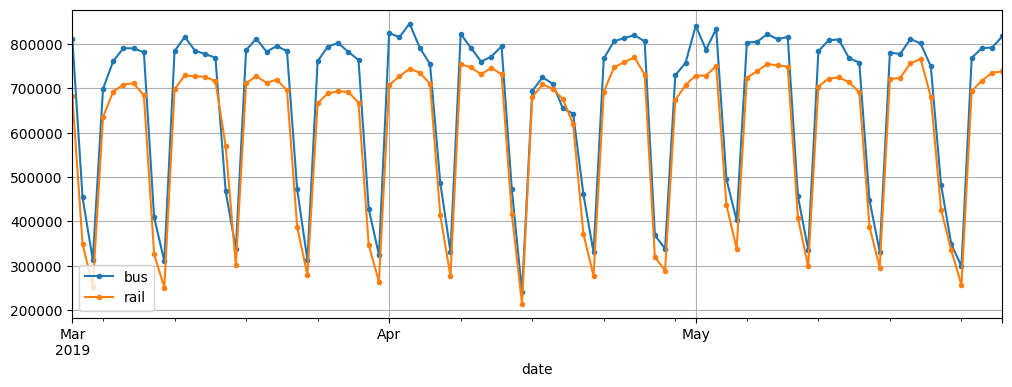

In [59]:
import matplotlib.pyplot as plt

# Set the date as the index
df = df.sort_values("date").set_index("date")


df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(12, 4))
plt.show()

In [60]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-3": "2019-05"]

diff_7


,bus,rail
date,,
2019-03-01,13927.0,-20019.0
2019-03-02,47280.0,21213.0
2019-03-03,25171.0,11672.0
2019-03-04,-63771.0,-45491.0
2019-03-05,-11268.0,-6517.0
...,...,...
2019-05-27,-482074.0,-464640.0
2019-05-28,-8578.0,-29490.0
2019-05-29,-20317.0,-38958.0


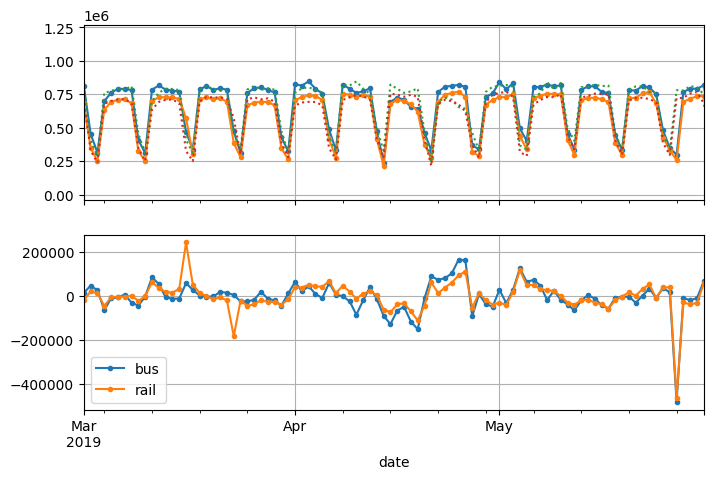

In [61]:
fig, axs = plt.subplots(2,1,sharex=True, figsize=(8,5))
df.plot(ax=axs[0], legend = False, marker=".") ## original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":") #lagged time series on the same plot

diff_7.plot(ax=axs[1], grid=True, marker=".") #differenced on the second plot
plt.show()


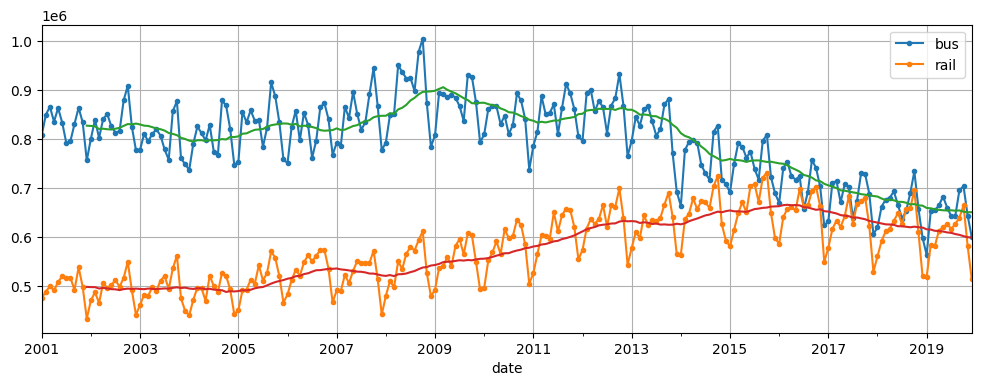

In [62]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample("ME").mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(12,4))
df_monthly[period].plot(ax=ax, marker =".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()


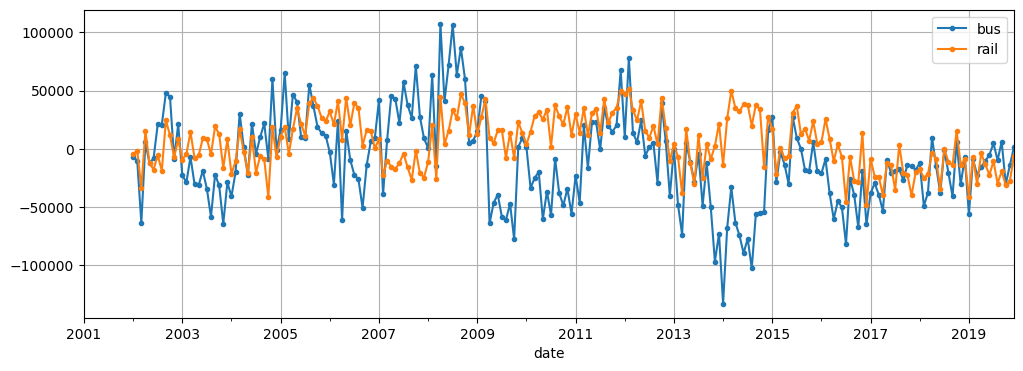

In [63]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(12,4))
plt.show()

In [64]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

## ARIMA MODEL

Let's predict the rail ridership for tomorrow, 1st June 2019

In [71]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"

# rail ridership from origin until today
# time series frequency: "Daily"
rail_series = df.loc[origin:today]["rail"].asfreq("D")

model = ARIMA(
    rail_series,
    order=(1, 0, 0),
    seasonal_order=(0,1,1,7)
)
model=model.fit()
y_pred = model.forecast()
print(f"the prediction is {y_pred}")
print(f"the real value is {df.loc["2019-06-01"]["rail"]}")
print(f"naive forecasting would have predicted: {df.shift(7).loc["2019-06-01"]["rail"]}")



the prediction is 2019-06-01    427758.626421
Freq: D, dtype: float64
the real value is 379044
naive forecasting would have predicted: 426932.0


In [79]:
# run the same code in a loop, making forecasts in march, april and may

origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")

y_preds = []

for today in time_period.shift(-1):
  model = ARIMA(rail_series[origin:today],
                order=(1,0,0),
                seasonal_order=(0,1,1,7))
  model = model.fit()
  y_pred = model.forecast().iloc[0]
  y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae=(y_preds-rail_series[time_period]).abs().mean()

In [77]:
print(f"the mean absolute error is {mae}")

the mean absolute error is 233343.518372994


In [80]:
# the mae with naive forecasting
y_naive = df.shift(7)[start_date:end_date]["rail"]
y_naive = pd.Series(y_naive, index=time_period)
mae_naive = (y_naive-rail_series[time_period]).abs().mean()
print(f"the mean absolute error is {mae_naive}")


the mean absolute error is 42143.27173913043


### let's run a simple grid search

In [82]:
import itertools

# Parameter Grid
p_values = [0, 1, 2]
d_values = [0]
q_values = [0, 1]

P_values = [0, 1]
D_values = [1]
Q_values = [0, 1]
s = 7  # Weekly seasonality

# Generate all possible combinations
grid = list(
    itertools.product(p_values, d_values, q_values, P_values, D_values, Q_values)
)

best_mae = float("inf") # set best mae to infinity
best_params = None
results = []


# Grid Search Loop
for p, d, q, P, D, Q in grid:
    order = (p, d, q)
    seasonal_order = (P, D, Q, s)
    y_preds = []

    for today in time_period.shift(-1):
      model = ARIMA(rail_series[origin:today],
                order=order,
                seasonal_order=seasonal_order)
      model = model.fit()
      y_pred = model.forecast().iloc[0]
      y_preds.append(y_pred)

    # Calculate metrics for the current parameter configuration
    y_preds_series = pd.Series(y_preds, index=time_period)
    mae = (y_preds_series - rail_series[time_period]).abs().mean()

    results.append({"order": order, "seasonal_order": seasonal_order, "mae": mae})
    print(
            f"Tested ARIMA{order}x{seasonal_order} - Validation MAE: {mae:.2f}"
        )

    # Track the optimal configuration
    if mae < best_mae:
      best_mae = mae
      best_params = (order, seasonal_order)


print("\n--- Search Grid Execution Optimal Parameters ---")
print(f"Best Configuration: ARIMA{best_params[0]}x{best_params[1]}")
print(f"Lowest Logged MAE: {best_mae:.2f}")

Tested ARIMA(0, 0, 0)x(0, 1, 0, 7) - Validation MAE: 42143.27
Tested ARIMA(0, 0, 0)x(0, 1, 1, 7) - Validation MAE: 38925.16
Tested ARIMA(0, 0, 0)x(1, 1, 0, 7) - Validation MAE: 39933.35
Tested ARIMA(0, 0, 0)x(1, 1, 1, 7) - Validation MAE: 38358.22
Tested ARIMA(0, 0, 1)x(0, 1, 0, 7) - Validation MAE: 41952.55
Tested ARIMA(0, 0, 1)x(0, 1, 1, 7) - Validation MAE: 38125.37
Tested ARIMA(0, 0, 1)x(1, 1, 0, 7) - Validation MAE: 39767.21
Tested ARIMA(0, 0, 1)x(1, 1, 1, 7) - Validation MAE: 38098.91
Tested ARIMA(1, 0, 0)x(0, 1, 0, 7) - Validation MAE: 37472.16
Tested ARIMA(1, 0, 0)x(0, 1, 1, 7) - Validation MAE: 32040.72
Tested ARIMA(1, 0, 0)x(1, 1, 0, 7) - Validation MAE: 34973.47
Tested ARIMA(1, 0, 0)x(1, 1, 1, 7) - Validation MAE: 32068.94
Tested ARIMA(1, 0, 1)x(0, 1, 0, 7) - Validation MAE: 42028.30
Tested ARIMA(1, 0, 1)x(0, 1, 1, 7) - Validation MAE: 36697.73
Tested ARIMA(1, 0, 1)x(1, 1, 0, 7) - Validation MAE: 38709.13
Tested ARIMA(1, 0, 1)x(1, 1, 1, 7) - Validation MAE: 35658.83
Tested A

## Preparing the data for ML models

In [ ]:
class TimeSeriesDataset(torch.utils.data.Dataset):
  def __init__(self, series, window_length):
    self.series = series #e.g 1000 days rail ridership
    self.window_length=window_length #e.g 56 days

  def __len__(self):
    # how many training examples can we extract
    return len(self.series) - self.window_length

  def __getitem__(self, index):
    if index >= len(self): # example no. index (e.g 2)
      raise IndexError("dataset index out of range")

    end = index + self.window_length #1st index after window (e.g. 58)
    window = self.series[index:end] # e.g. elements [2, 3, 4, ..., 57]
    target = self.series[end] # e.g element 58, the target
    return window, target